In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#load dataset
data = pd.read_csv(r"C:\Users\Han Eswaynne\Downloads\studentPerformance.csv")

#display first 5
print(data.head())

#check rows and columns
print("Dataset shape:", data.shape)

#check column name and data type
print("\nColumn name:")
print(data.columns.tolist())

print("\nDataset information:")
print(data.info())

#check missing value and duplicate records
print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicates:", data.duplicated().sum())

# Check final-grade distribution
print("\nFinal grade distribution:")
print(data["final_grade"].value_counts())

   age  gender school_type parent_education  study_hours  \
0   14    male      public    post graduate          3.1   
1   18  female      public         graduate          3.7   
2   17  female     private    post graduate          7.9   
3   16   other      public      high school          1.1   
4   16  female      public      high school          1.3   

   attendance_percentage internet_access extra_activities study_method  \
0                   84.3             yes              yes        notes   
1                   87.8             yes               no     textbook   
2                   65.5              no               no        notes   
3                   58.1              no               no        notes   
4                   61.0             yes              yes  group study   

   math_score  science_score  english_score final_grade  
0        42.7           55.4           57.0           e  
1        57.6           68.8           64.8           d  
2        84.8       

In [3]:
#input features
features = ["age", "gender", "school_type", "parent_education", "study_hours", "study_method", "internet_access", "attendance_percentage", "extra_activities", "math_score", "science_score", "english_score"]

#X input feature
X = data[features]

#y output
y = data["final_grade"]

print("\nFirst five X rows:")
print(X.head())

print("\nFirst five y values:")
print(y.head())

print("\nFinal grade classes:")
print(y.value_counts())


First five X rows:
   age  gender school_type parent_education  study_hours study_method  \
0   14    male      public    post graduate          3.1        notes   
1   18  female      public         graduate          3.7     textbook   
2   17  female     private    post graduate          7.9        notes   
3   16   other      public      high school          1.1        notes   
4   16  female      public      high school          1.3  group study   

  internet_access  attendance_percentage extra_activities  math_score  \
0             yes                   84.3              yes        42.7   
1             yes                   87.8               no        57.6   
2              no                   65.5               no        84.8   
3              no                   58.1               no        44.4   
4             yes                   61.0              yes         8.9   

   science_score  english_score  
0           55.4           57.0  
1           68.8           64.8  


In [4]:
#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20000, 12)
X_test shape: (5000, 12)
y_train shape: (20000,)
y_test shape: (5000,)


In [5]:
#numerical variables: scale them
numeric_columns = ["age", "study_hours", "attendance_percentage", "math_score", "science_score", "english_score"]

#categorical variables:
categorical_columns = ["gender", "school_type", "parent_education", "study_method", "internet_access", "extra_activities"]

#build data preprocessor
preprocessor = ColumnTransformer(transformers=[("numeric", StandardScaler(), numeric_columns),
                                               ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)])

#fit preprocessing using training data
X_train_processed = preprocessor.fit_transform(X_train)

#apply the same preprocessing to unseen test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (20000, 27)
Processed testing data shape: (5000, 27)


In [6]:
models = {"Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
          "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
          "Support Vector Machine": SVC(random_state=42),
          "Artificial Neural Network": MLPClassifier(random_state=42, max_iter=2000)}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():

    #train model using processed training data
    model.fit(X_train_processed, y_train)

    #predict final grades using processed test data
    y_pred = model.predict(X_test_processed)

    #store model and prediction
    trained_models[name] = model
    predictions[name] = y_pred

    #calculate multi-class evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    #add results to comparison list
    results.append({"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1})

    print(f"\n{name}")
    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))


Logistic Regression
Accuracy: 0.762
Precision: 0.762
Recall: 0.762
F1-score: 0.762


C:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^


K-Nearest Neighbors
Accuracy: 0.704
Precision: 0.705
Recall: 0.704
F1-score: 0.704

Support Vector Machine
Accuracy: 0.779
Precision: 0.779
Recall: 0.779
F1-score: 0.779

Artificial Neural Network
Accuracy: 0.789
Precision: 0.788
Recall: 0.789
F1-score: 0.788


In [7]:
results_df = pd.DataFrame(results)

#sort models from highest to lowest F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("\nModel Comparison Results:")
print(results_df.round(3))


Model Comparison Results:
                       Model  Accuracy  Precision  Recall  F1-score
0  Artificial Neural Network     0.789      0.788   0.789     0.788
1     Support Vector Machine     0.779      0.779   0.779     0.779
2        Logistic Regression     0.762      0.762   0.762     0.762
3        K-Nearest Neighbors     0.704      0.705   0.704     0.704


Best model: Artificial Neural Network
Grade labels: ['a', 'b', 'c', 'd', 'e', 'f']

Confusion Matrix:
[[ 172   68    1    0    0    0]
 [  50  354  135    0    0    0]
 [   2   81 1036  112    1    0]
 [   0    0  144 1018  100    0]
 [   0    0    0  152  888   95]
 [   0    0    0    0  115  476]]


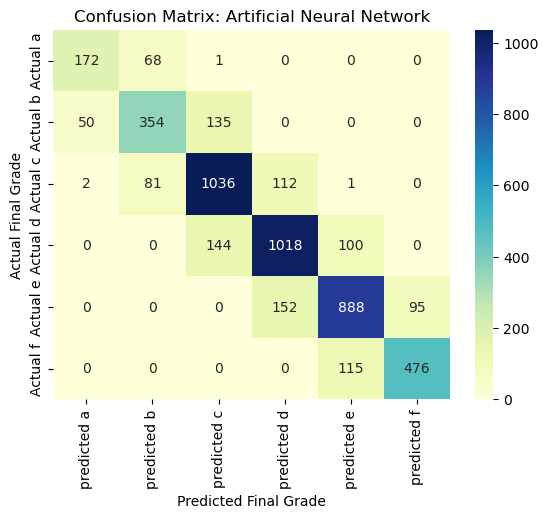

In [8]:
#Select the model with the highest F1-score
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_prediction = predictions[best_model_name]

print("Best model:", best_model_name)

#obtain grade labels
grade_labels = sorted(y.unique())

print("Grade labels:", grade_labels)

#build confusion matrix
cm = confusion_matrix(y_test, best_prediction, labels=grade_labels)

print("\nConfusion Matrix:")
print(cm)

#display graph
sns.heatmap(cm, xticklabels=[f"predicted {grade}" for grade in grade_labels],
            yticklabels=[f"Actual {grade}" for grade in grade_labels],
            annot=True, fmt="d", cmap="YlGnBu")

plt.xlabel("Predicted Final Grade")
plt.ylabel("Actual Final Grade")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [9]:
#save preprocessing object
joblib.dump(preprocessor, "student_performance_preprocessor.joblib")

#save best trained classifier
joblib.dump(best_model, "student_performance_best_model.joblib")

print("Preprocessor and best model saved successfully.")

Preprocessor and best model saved successfully.


In [10]:
for column in categorical_columns:
    print(column, ":", data[column].unique())

# New student data
new_student = pd.DataFrame([{
    "age": 17,
    "gender": "Female",
    "school_type": "Public",
    "parent_education": "Bachelor",
    "study_hours": 3.5,
    "study_method": "Self-study",
    "internet_access": "Yes",
    "attendance_percentage": 92.0,
    "extra_activities": "Yes",
    "math_score": 78,
    "science_score": 82,
    "english_score": 75
}])

# Apply the already-fitted preprocessor
new_student_processed = preprocessor.transform(new_student)

# Predict final grade using best model
prediction = best_model.predict(new_student_processed)[0]

print("Predicted student final grade:", prediction)

gender : ['male' 'female' 'other']
school_type : ['public' 'private']
parent_education : ['post graduate' 'graduate' 'high school' 'no formal' 'diploma' 'phd']
study_method : ['notes' 'textbook' 'group study' 'coaching' 'mixed' 'online videos']
internet_access : ['yes' 'no']
extra_activities : ['yes' 'no']
Predicted student final grade: c
